# Conditional (Temporal) RBM — Plankton Time Series

A **Conditional RBM** (cRBM; Taylor et al. 2006) extends the standard RBM by adding autoregressive connections from the previous time step's visible units. This modifies the hidden and visible biases dynamically, so the model learns *transitions* between community states rather than treating each day as independent.

**Architecture (Gaussian-visible, Bernoulli-hidden):**
```
v_{t-1}  →  A  →  b_h_dynamic  ─┐
                                  ├── hidden h_t
v_t      →  W  ──────────────────┘

v_{t-1}  →  B  →  b_v_dynamic  ─┐
                                  ├── visible v_t (Gaussian)
h_t      →  W.T ────────────────┘
```

In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import expit as sigmoid
import warnings
warnings.filterwarnings('ignore')
rng = np.random.default_rng(42)

In [17]:
# ── Load & preprocess ─────────────────────────────────────────────────────────
df = pd.read_csv('TimeSeries_countsuL_clean.csv', index_col=0, parse_dates=True)
df = df.dropna(how='all').fillna(0)

# ── Filter 1: prevalence — drop species absent on > 95% of days ───────────────
MIN_PREVALENCE = 0.05
presence       = (df > 0).mean(axis=0)
keep_prev      = presence >= MIN_PREVALENCE

# ── Filter 2: variance — log-transform first, then check std ──────────────────
# A species always present at ~constant density has log-std ≈ 0 after transform
# and conveys no correlational information.
eps_all   = df[df > 0].min().min() * 0.1
X_all_log = np.log10(df.values + eps_all)
log_std   = X_all_log.std(axis=0)

MIN_LOG_STD = 0.5    # ~half an order of magnitude variation in log10 space
keep_var    = log_std >= MIN_LOG_STD

keep = keep_prev & keep_var
print(f'Total species       : {len(df.columns)}')
print(f'Low prevalence (<{MIN_PREVALENCE*100:.0f}%): {(~keep_prev).sum()} dropped')
print(f'Low log-variance    : {(keep_prev & ~keep_var).sum()} dropped')
print(f'Remaining           : {keep.sum()}')

df      = df.loc[:, keep]
species = df.columns.tolist()

# ── Log-transform + standardise retained species ──────────────────────────────
eps   = df[df > 0].min().min() * 0.1
X_raw = np.log10(df.values + eps).astype(np.float32)

mu  = X_raw.mean(0, keepdims=True)
sig = X_raw.std(0, keepdims=True) + 1e-8
X   = (X_raw - mu) / sig

T, n_vis = X.shape
dates    = df.index

# ── 80/20 chronological train / validation split ──────────────────────────────
split   = int(0.8 * T)
X_train = X[:split]
X_val   = X[split:]
T_train = len(X_train)

print(f'\nData shape : {X.shape}  ({T} days, {n_vis} species)')
print(f'Train      : {T_train} days  ({dates[0].date()} → {dates[split-1].date()})')
print(f'Validation : {len(X_val)} days  ({dates[split].date()} → {dates[-1].date()})')

# ── Validation MSE helper ─────────────────────────────────────────────────────
def compute_val_mse(model, X_v):
    """One-step-ahead reconstruction MSE on a held-out sequence."""
    errs = []
    for t in range(1, len(X_v)):
        hp    = model.h_given_v(X_v[t], X_v[t-1])
        v_rec = model.v_given_h(hp, X_v[t-1])
        errs.append(float(np.mean((X_v[t] - v_rec) ** 2)))
    return float(np.mean(errs))

Total species       : 83
Low prevalence (<5%): 2 dropped
Low log-variance    : 0 dropped
Remaining           : 81

Data shape : (2066, 81)  (2066 days, 81 species)
Train      : 1652 days  (2019-03-26 → 2023-11-11)
Validation : 414 days  (2023-11-12 → 2024-12-31)


In [19]:
class ConditionalRBM:
    """
    Gaussian-visible / Bernoulli-hidden Conditional RBM.
    Autoregressive order = 1 (conditions on previous time step only).
    Trained with Contrastive Divergence k=1 (CD-1).
    """

    def __init__(self, n_visible, n_hidden, lr=1e-3, momentum=0.9, l2=1e-4):
        self.nv, self.nh = n_visible, n_hidden
        self.lr, self.mom, self.l2 = lr, momentum, l2

        # RBM weights + biases
        self.W  = rng.normal(0, 0.01, (n_hidden, n_visible)).astype(np.float32)
        self.bh = np.zeros(n_hidden,  dtype=np.float32)
        self.bv = np.zeros(n_visible, dtype=np.float32)

        # Autoregressive weights  (past visible → dynamic biases)
        self.A  = rng.normal(0, 0.01, (n_hidden,  n_visible)).astype(np.float32)  # → hidden bias
        self.B  = rng.normal(0, 0.01, (n_visible, n_visible)).astype(np.float32)  # → visible bias

        # Momentum buffers
        self._dW = np.zeros_like(self.W)
        self._dbh = np.zeros_like(self.bh)
        self._dbv = np.zeros_like(self.bv)
        self._dA  = np.zeros_like(self.A)
        self._dB  = np.zeros_like(self.B)

    # ── Conditional distributions ─────────────────────────────────────────────
    def _bh_dyn(self, v_prev):  return self.bh + self.A @ v_prev
    def _bv_dyn(self, v_prev):  return self.bv + self.B @ v_prev

    def h_given_v(self, v, v_prev):
        """P(h=1 | v_t, v_{t-1})  — shape (n_hidden,)"""
        return sigmoid(self.W @ v + self._bh_dyn(v_prev))

    def v_given_h(self, h, v_prev):
        """Mean of P(v_t | h_t, v_{t-1}) — Gaussian mean"""
        return self.W.T @ h + self._bv_dyn(v_prev)

    # ── CD-1 step ─────────────────────────────────────────────────────────────
    def cd1_step(self, v, v_prev):
        # Positive phase
        hp = self.h_given_v(v, v_prev)
        hs = (rng.random(self.nh) < hp).astype(np.float32)   # sample

        # Negative phase (Gibbs step)
        v_neg = self.v_given_h(hs, v_prev)                    # Gaussian mean
        hn    = self.h_given_v(v_neg, v_prev)

        # Gradients
        dW  = np.outer(hp, v) - np.outer(hn, v_neg)
        dbh = hp - hn
        dbv = v  - v_neg
        dA  = np.outer(hp - hn, v_prev)
        dB  = np.outer(v  - v_neg, v_prev)

        # Momentum + L2
        lr = self.lr
        self._dW  = self.mom * self._dW  + lr * (dW  - self.l2 * self.W)
        self._dbh = self.mom * self._dbh + lr * dbh
        self._dbv = self.mom * self._dbv + lr * dbv
        self._dA  = self.mom * self._dA  + lr * (dA  - self.l2 * self.A)
        self._dB  = self.mom * self._dB  + lr * (dB  - self.l2 * self.B)

        self.W  += self._dW;  self.bh += self._dbh
        self.bv += self._dbv; self.A  += self._dA;  self.B += self._dB

        return float(np.mean((v - v_neg) ** 2))   # reconstruction MSE

    # ── Encode full sequence → hidden activations ─────────────────────────────
    def encode(self, X):
        H = np.zeros((len(X) - 1, self.nh), dtype=np.float32)
        for t in range(1, len(X)):
            H[t-1] = self.h_given_v(X[t], X[t-1])
        return H

    # ── Reconstruct sequence ──────────────────────────────────────────────────
    def reconstruct(self, X):
        V_rec = np.zeros_like(X[1:])
        for t in range(1, len(X)):
            hp     = self.h_given_v(X[t], X[t-1])
            V_rec[t-1] = self.v_given_h(hp, X[t-1])
        return V_rec

In [ ]:
# ── Single-model training (train on X_train, early-stop on val MSE) ───────────
N_HIDDEN   = 15
N_EPOCHS   = 1000
LR         = 5e-4
PATIENCE   = 100
BATCH_SIZE = 32

crbm = ConditionalRBM(n_vis, N_HIDDEN, lr=LR, momentum=0.9, l2=1e-4)

train_history = []
val_history   = []
best_val_mse  = np.inf
best_snap     = None
no_improve    = 0

for epoch in range(N_EPOCHS):
    # ── Mini-batch training on X_train ────────────────────────────────────────
    mse_epoch = []
    idx = rng.permutation(np.arange(1, T_train))

    for batch_start in range(0, len(idx), BATCH_SIZE):
        batch = idx[batch_start : batch_start + BATCH_SIZE]
        dW  = np.zeros_like(crbm.W);  dbh = np.zeros_like(crbm.bh)
        dbv = np.zeros_like(crbm.bv); dA  = np.zeros_like(crbm.A); dB = np.zeros_like(crbm.B)
        b_mse = []

        for t in batch:
            v, vp = X_train[t], X_train[t-1]
            hp  = crbm.h_given_v(v, vp)
            hs  = (rng.random(crbm.nh) < hp).astype(np.float32)
            v_n = crbm.v_given_h(hs, vp)                   # sampled  — used for gradient only
            hn  = crbm.h_given_v(v_n, vp)
            dW  += np.outer(hp, v)   - np.outer(hn, v_n)
            dbh += hp - hn;  dbv += v - v_n
            dA  += np.outer(hp - hn, vp);  dB += np.outer(v - v_n, vp)
            v_mf = crbm.v_given_h(hp, vp)                  # mean-field — used for MSE logging
            b_mse.append(float(np.mean((v - v_mf) ** 2)))

        n = len(batch); lr = crbm.lr
        crbm._dW  = crbm.mom*crbm._dW  + lr*(dW/n  - crbm.l2*crbm.W)
        crbm._dbh = crbm.mom*crbm._dbh + lr*(dbh/n)
        crbm._dbv = crbm.mom*crbm._dbv + lr*(dbv/n)
        crbm._dA  = crbm.mom*crbm._dA  + lr*(dA/n  - crbm.l2*crbm.A)
        crbm._dB  = crbm.mom*crbm._dB  + lr*(dB/n  - crbm.l2*crbm.B)
        crbm.W  += crbm._dW;  crbm.bh += crbm._dbh
        crbm.bv += crbm._dbv; crbm.A  += crbm._dA;  crbm.B += crbm._dB
        mse_epoch.extend(b_mse)

    train_history.append(float(np.mean(mse_epoch)))

    # ── Validation MSE (early-stopping criterion) ─────────────────────────────
    v_mse = compute_val_mse(crbm, X_val)
    val_history.append(v_mse)

    if v_mse < best_val_mse:
        best_val_mse = v_mse
        best_snap    = copy.deepcopy(crbm)
        no_improve   = 0
    else:
        no_improve  += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:4d}  |  train MSE = {train_history[-1]:.4f}'
              f'  |  val MSE = {v_mse:.4f}'
              f'  |  best val = {best_val_mse:.4f}'
              f'  |  patience = {no_improve}/{PATIENCE}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}.')
        break

# Restore best weights
crbm = best_snap
best_mse = best_val_mse
print(f'\nBest val MSE = {best_val_mse:.4f}  (R² ≈ {1 - best_val_mse:.2f})')

Epoch   10  |  recon MSE = 0.3943  |  best = 0.3943  |  no-improve = 0/100
Epoch   20  |  recon MSE = 0.3851  |  best = 0.3851  |  no-improve = 0/100
Epoch   30  |  recon MSE = 0.3796  |  best = 0.3796  |  no-improve = 0/100
Epoch   40  |  recon MSE = 0.3761  |  best = 0.3757  |  no-improve = 1/100
Epoch   50  |  recon MSE = 0.3723  |  best = 0.3723  |  no-improve = 0/100
Epoch   60  |  recon MSE = 0.3698  |  best = 0.3687  |  no-improve = 1/100
Epoch   70  |  recon MSE = 0.3682  |  best = 0.3672  |  no-improve = 2/100
Epoch   80  |  recon MSE = 0.3651  |  best = 0.3651  |  no-improve = 0/100
Epoch   90  |  recon MSE = 0.3651  |  best = 0.3643  |  no-improve = 8/100
Epoch  100  |  recon MSE = 0.3648  |  best = 0.3643  |  no-improve = 3/100
Epoch  110  |  recon MSE = 0.3646  |  best = 0.3634  |  no-improve = 6/100
Epoch  120  |  recon MSE = 0.3645  |  best = 0.3634  |  no-improve = 16/100
Epoch  130  |  recon MSE = 0.3642  |  best = 0.3625  |  no-improve = 1/100
Epoch  140  |  recon MSE

  N_hidden = 400  |  val MSE = 0.2218  |  train MSE = 0.4005  |  patience = 2000  |  stopped @ epoch 1000

Best N_hidden = 400  (val MSE = 0.2218,  R² ≈ 0.78)


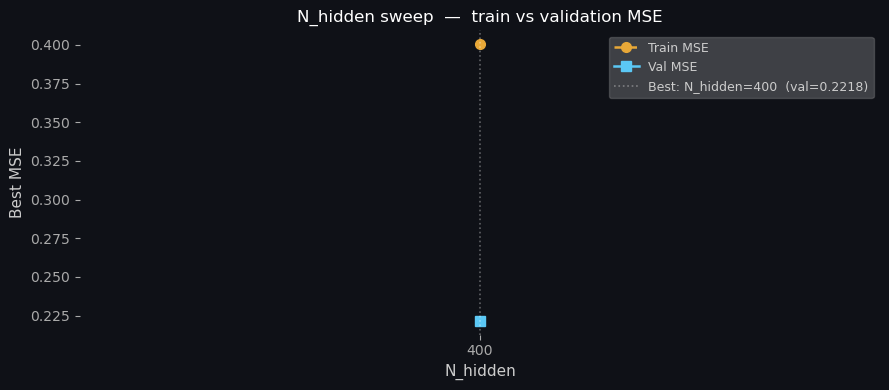

In [ ]:
# ── N_HIDDEN sweep (val MSE for selection, patience scaled by model size) ──────
import copy

SWEEP_HIDDEN = [400]
SWEEP_EPOCHS = 1000
SWEEP_BATCH  = 32

sweep_train_mse = {}
sweep_val_mse   = {}
sweep_models    = {}

for nh in SWEEP_HIDDEN:
    patience_nh = max(50, nh * 5)
    m           = ConditionalRBM(n_vis, nh, lr=LR, momentum=0.9, l2=1e-4)
    best_v      = np.inf
    best_t      = np.inf
    no_imp      = 0
    best_m      = None

    for epoch in range(SWEEP_EPOCHS):
        mse_ep = []
        idx    = rng.permutation(np.arange(1, T_train))

        for batch_start in range(0, len(idx), SWEEP_BATCH):
            batch = idx[batch_start : batch_start + SWEEP_BATCH]
            dW  = np.zeros_like(m.W);  dbh = np.zeros_like(m.bh)
            dbv = np.zeros_like(m.bv); dA  = np.zeros_like(m.A); dB = np.zeros_like(m.B)
            b_mse = []

            for t in batch:
                v, vp = X_train[t], X_train[t-1]
                hp  = m.h_given_v(v, vp)
                hs  = (rng.random(m.nh) < hp).astype(np.float32)
                v_n = m.v_given_h(hs, vp)                  # sampled  — gradient only
                hn  = m.h_given_v(v_n, vp)
                dW  += np.outer(hp, v)   - np.outer(hn, v_n)
                dbh += hp - hn;  dbv += v - v_n
                dA  += np.outer(hp - hn, vp);  dB += np.outer(v - v_n, vp)
                v_mf = m.v_given_h(hp, vp)                 # mean-field — MSE logging
                b_mse.append(float(np.mean((v - v_mf) ** 2)))

            n = len(batch); lr = m.lr
            m._dW  = m.mom*m._dW  + lr*(dW/n  - m.l2*m.W)
            m._dbh = m.mom*m._dbh + lr*(dbh/n)
            m._dbv = m.mom*m._dbv + lr*(dbv/n)
            m._dA  = m.mom*m._dA  + lr*(dA/n  - m.l2*m.A)
            m._dB  = m.mom*m._dB  + lr*(dB/n  - m.l2*m.B)
            m.W  += m._dW;  m.bh += m._dbh
            m.bv += m._dbv; m.A  += m._dA; m.B += m._dB
            mse_ep.extend(b_mse)

        ep_train = float(np.mean(mse_ep))
        ep_val   = compute_val_mse(m, X_val)

        if ep_val < best_v:
            best_v = ep_val
            best_t = ep_train
            no_imp = 0
            best_m = copy.deepcopy(m)
        else:
            no_imp += 1
        if no_imp >= patience_nh:
            break

    sweep_train_mse[nh] = best_t
    sweep_val_mse[nh]   = best_v
    sweep_models[nh]    = best_m
    print(f'  N_hidden = {nh:3d}  |  val MSE = {best_v:.4f}'
          f'  |  train MSE = {best_t:.4f}'
          f'  |  patience = {patience_nh}'
          f'  |  stopped @ epoch {epoch+1}')

# ── Pick best by validation MSE ────────────────────────────────────────────────
best_nh  = min(sweep_val_mse, key=sweep_val_mse.get)
best_mse = sweep_val_mse[best_nh]
crbm     = sweep_models[best_nh]
N_HIDDEN = best_nh
print(f'\nBest N_hidden = {best_nh}  (val MSE = {best_mse:.4f},  R² ≈ {1-best_mse:.2f})')

# ── Plot train vs val MSE across sweep ────────────────────────────────────────
nh_vals = list(sweep_val_mse.keys())
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0f1117')
ax.set_facecolor('#0f1117')
ax.plot(nh_vals, [sweep_train_mse[k] for k in nh_vals],
        'o--', color='#e8a838', linewidth=1.8, markersize=7, label='Train MSE (mean-field)')
ax.plot(nh_vals, [sweep_val_mse[k]   for k in nh_vals],
        's-',  color='#5bc8f5', linewidth=1.8, markersize=7, label='Val MSE (mean-field)')
ax.axvline(best_nh, color='#ffffff55', linestyle=':', linewidth=1.2,
           label=f'Best: N_hidden={best_nh}  (val={best_mse:.4f})')
ax.set_xlabel('N_hidden', color='#cccccc', fontsize=11)
ax.set_ylabel('Best MSE', color='#cccccc', fontsize=11)
ax.set_title('N_hidden sweep  —  train vs validation MSE  (both mean-field)', color='white', fontsize=12)
ax.tick_params(colors='#aaaaaa'); ax.set_xticks(nh_vals)
ax.legend(fontsize=9, framealpha=0.2, labelcolor='#cccccc')
[s.set_visible(False) for s in ax.spines.values()]
plt.tight_layout()
plt.savefig('crbm_sweep.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
#val MSE = 0.2227 200
#val MSE = 0.2233 150


In [8]:
# ── Encode sequence + reconstruct ─────────────────────────────────────────────
H     = crbm.encode(X)       # (T-1, N_HIDDEN)  — latent community trajectory
V_rec = crbm.reconstruct(X)  # (T-1, n_vis)     — reconstructed densities

dates_enc = dates[1:]         # dates align with encoded steps

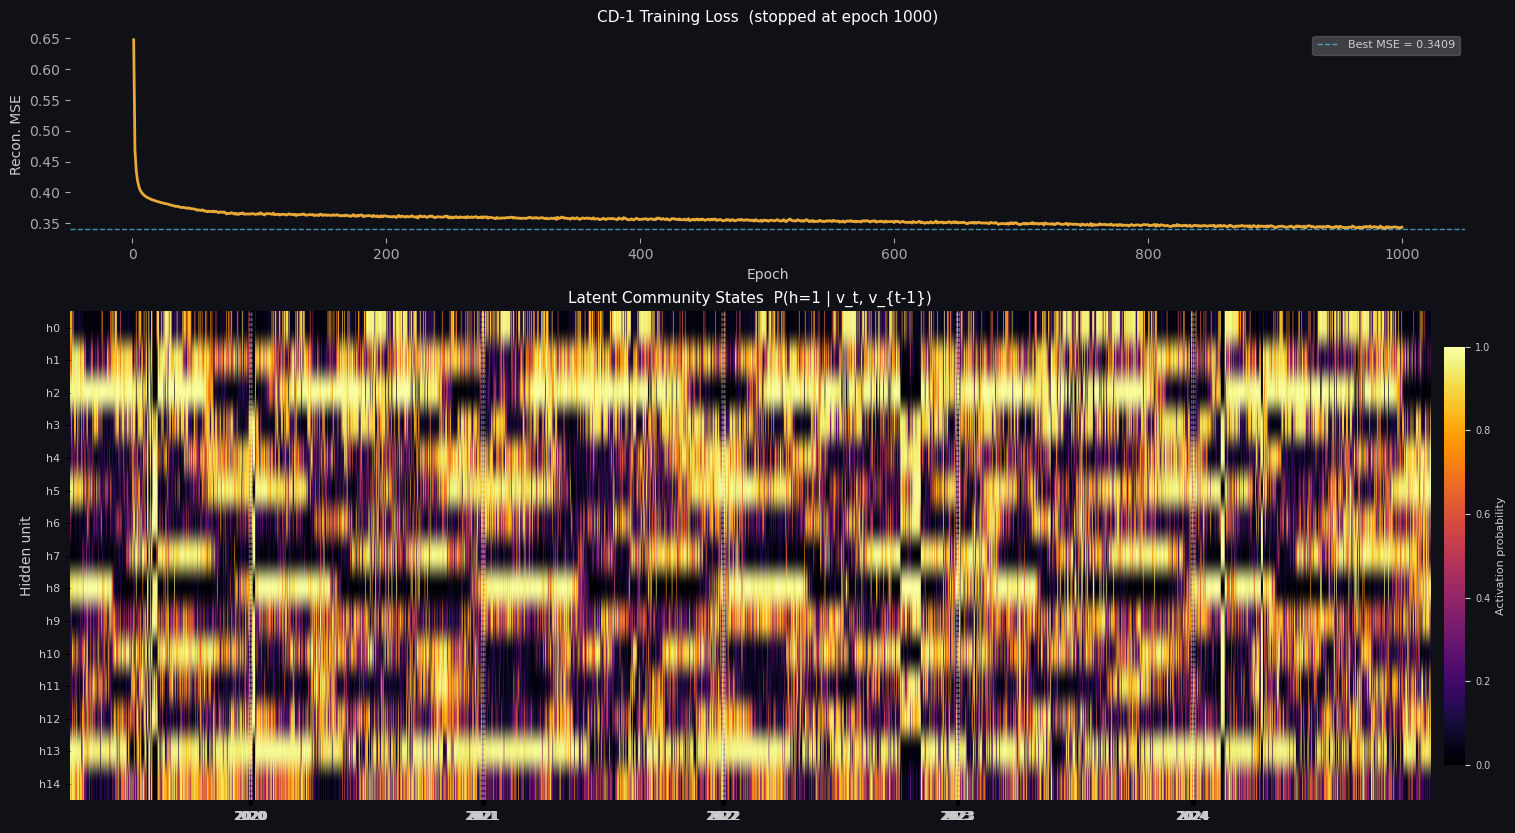

In [ ]:
# ── Figure 1: Training curve + hidden unit activations over time ───────────────
n_epochs_run = len(train_history)

fig = plt.figure(figsize=(18, 10), facecolor='#0f1117')
gs  = gridspec.GridSpec(3, 1, hspace=0.35)

# -- Train vs validation loss -------------------------------------------------
ax0 = fig.add_subplot(gs[0])
ax0.set_facecolor('#0f1117')
epochs_x = range(1, n_epochs_run + 1)
ax0.plot(epochs_x, train_history, color='#e8a838', linewidth=1.5, label='Train MSE')
ax0.plot(epochs_x, val_history,   color='#5bc8f5', linewidth=1.5, label='Val MSE')
ax0.axhline(best_val_mse, color='#5bc8f5', linewidth=1, linestyle='--', alpha=0.6,
            label=f'Best val = {best_val_mse:.4f}')
ax0.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')
ax0.set_xlabel('Epoch', color='#cccccc')
ax0.set_ylabel('Recon. MSE', color='#cccccc')
ax0.set_title(f'CD-1 Training Loss  (N_hidden={N_HIDDEN},  stopped @ epoch {n_epochs_run})',
              color='white', fontsize=11)
ax0.tick_params(colors='#aaaaaa')
[s.set_visible(False) for s in ax0.spines.values()]

# -- Hidden activations heatmap -----------------------------------------------
ax1 = fig.add_subplot(gs[1:3])
ax1.set_facecolor('#0f1117')
im = ax1.imshow(H.T, aspect='auto', cmap='inferno', vmin=0, vmax=1,
                extent=[0, len(dates_enc), N_HIDDEN, 0])

jan_pos = [i for i, d in enumerate(dates_enc) if d.month == 1 and d.day <= 7]
jan_lbl = [str(dates_enc[i].year) for i in jan_pos]
ax1.set_xticks(jan_pos); ax1.set_xticklabels(jan_lbl, color='#cccccc', fontsize=9)
for xi in jan_pos:
    ax1.axvline(xi, color='#ffffff33', linewidth=0.7, linestyle='--')

ax1.set_yticks(np.arange(N_HIDDEN) + 0.5)
ax1.set_yticklabels([f'h{i}' for i in range(N_HIDDEN)], color='#cccccc', fontsize=8)
ax1.set_ylabel('Hidden unit', color='#cccccc', fontsize=10)
ax1.set_title('Latent Community States  P(h=1 | v_t, v_{t-1})', color='white', fontsize=11)
[s.set_visible(False) for s in ax1.spines.values()]

cb = fig.colorbar(im, ax=ax1, fraction=0.015, pad=0.01)
cb.set_label('Activation probability', color='#cccccc', fontsize=8)
cb.ax.yaxis.set_tick_params(color='#cccccc', labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

plt.savefig('crbm_hidden_activations.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

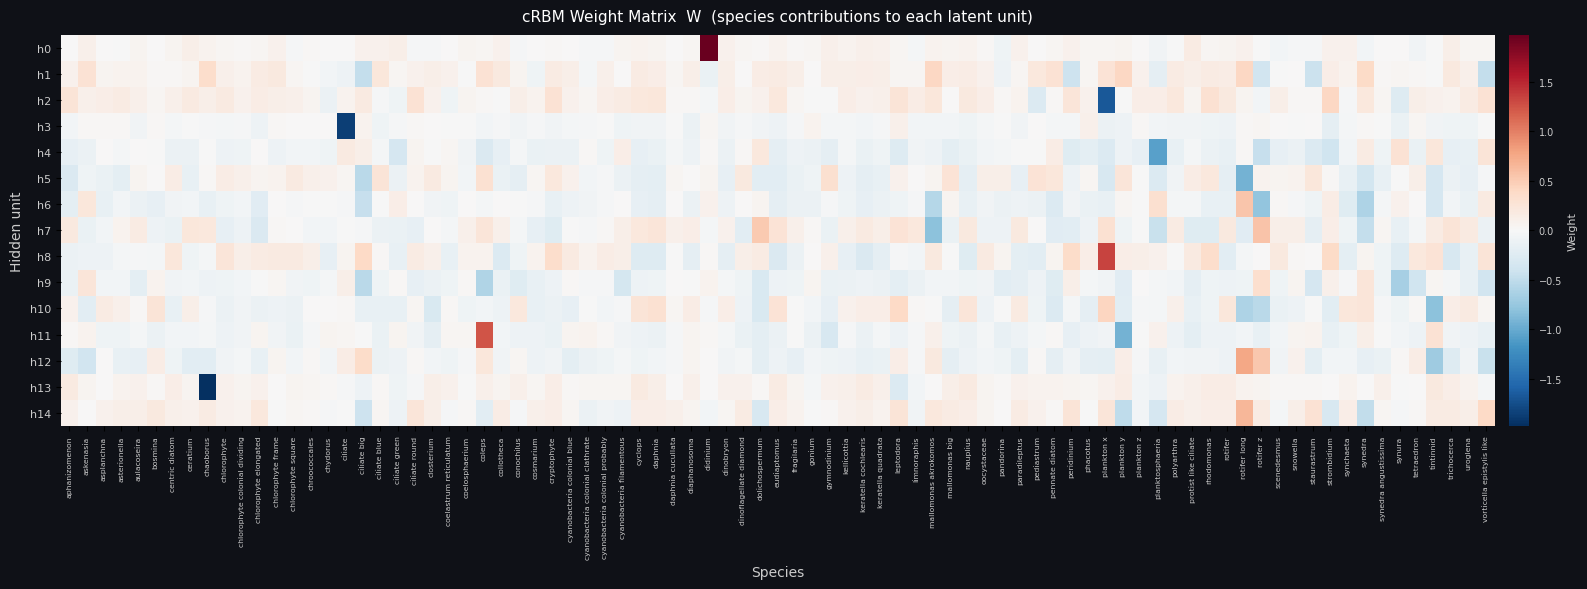

In [10]:
# ── Figure 2: Weight matrix — which species drive each hidden unit ─────────────
fig, ax = plt.subplots(figsize=(16, 6), facecolor='#0f1117')
ax.set_facecolor('#0f1117')

vmax = np.abs(crbm.W).max()
im = ax.imshow(crbm.W, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(n_vis))
ax.set_xticklabels([s.replace('_', ' ') for s in species],
                   rotation=90, fontsize=5.5, color='#cccccc')
ax.set_yticks(range(N_HIDDEN))
ax.set_yticklabels([f'h{i}' for i in range(N_HIDDEN)], fontsize=8, color='#cccccc')
ax.set_xlabel('Species', color='#cccccc', fontsize=10)
ax.set_ylabel('Hidden unit', color='#cccccc', fontsize=10)
ax.set_title('cRBM Weight Matrix  W  (species contributions to each latent unit)',
             color='white', fontsize=11, pad=10)
[s.set_visible(False) for s in ax.spines.values()]

cb = fig.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
cb.set_label('Weight', color='#cccccc', fontsize=8)
cb.ax.yaxis.set_tick_params(labelsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#cccccc')
cb.outline.set_visible(False)

plt.tight_layout()
plt.savefig('crbm_weights.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

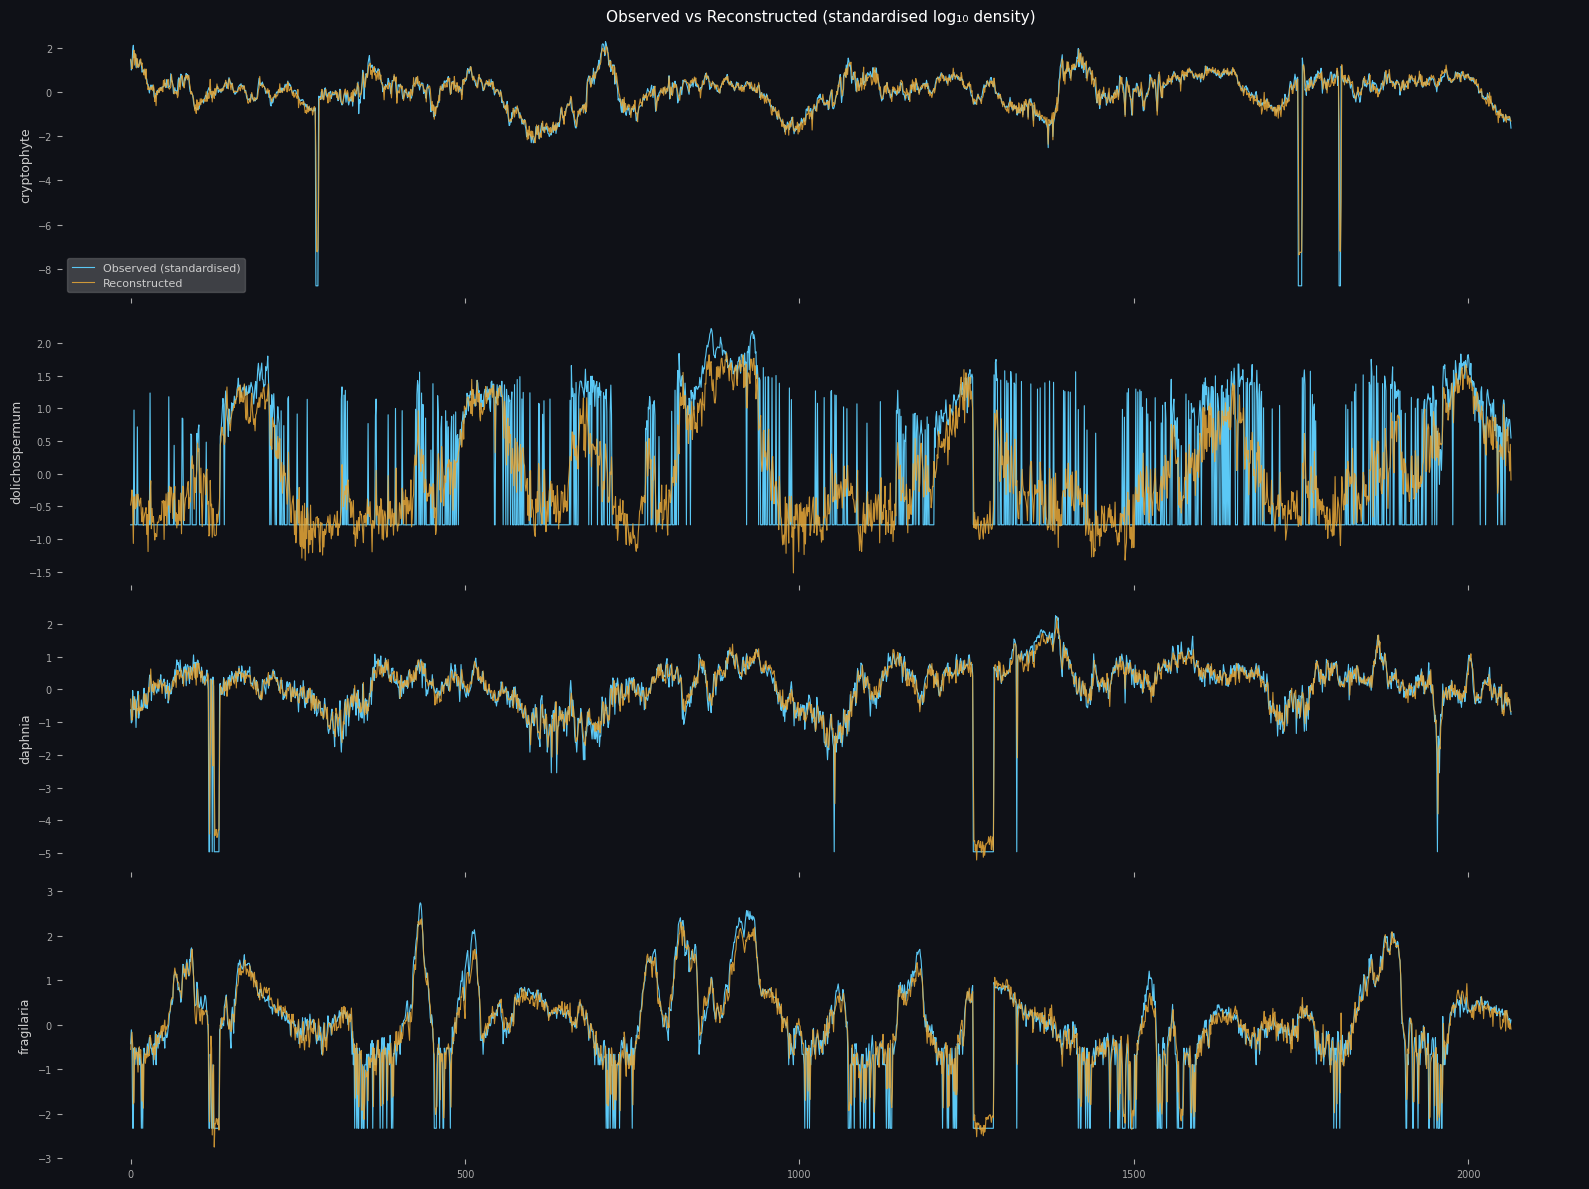

In [11]:
# ── Figure 3: Reconstruction quality for a few species ────────────────────────
# Pick 4 ecologically interesting taxa to compare
check_species = ['cryptophyte', 'dolichospermum', 'daphnia', 'fragilaria']
check_species = [s for s in check_species if s in species]   # guard against missing

fig, axes = plt.subplots(len(check_species), 1, figsize=(16, 3*len(check_species)),
                         sharex=True, facecolor='#0f1117')

for ax, sp in zip(axes, check_species):
    ax.set_facecolor('#0f1117')
    idx = species.index(sp)
    obs = X[1:, idx]
    rec = V_rec[:, idx]
    ax.plot(obs, color='#5bc8f5', linewidth=0.8, label='Observed (standardised)')
    ax.plot(rec, color='#e8a838', linewidth=0.8, alpha=0.85, label='Reconstructed')
    ax.set_ylabel(sp.replace('_',' '), color='#cccccc', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=7)
    [s.set_visible(False) for s in ax.spines.values()]
    if ax == axes[0]:
        ax.legend(fontsize=8, framealpha=0.2, labelcolor='#cccccc')
        ax.set_title('Observed vs Reconstructed (standardised log₁₀ density)',
                     color='white', fontsize=11)

plt.tight_layout()
plt.savefig('crbm_reconstruction.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

## Interpreting the outputs

| Output | Shape | Ecological meaning |
|---|---|---|
| `H` (hidden activations) | `(T-1, 15)` | Daily probability of each latent community state being active — the compressed trajectory of community dynamics |
| `crbm.W` (weight matrix) | `(15, 82)` | Which species positively/negatively define each hidden unit |
| `crbm.A` (AR→hidden) | `(15, 82)` | How yesterday's community composition biases today's latent states — encodes transition rules |
| `crbm.B` (AR→visible) | `(82, 82)` | Direct species-to-species temporal carry-over effects |

**Next steps:**
- Vary `N_HIDDEN` (try 5–30) and compare reconstruction MSE
- Cluster hidden activation patterns to find recurring community regimes
- Use `H` as features for downstream prediction (e.g. bloom forecasting)